**Download Dataset**

In [1]:
# Query Zenodo record metadata to see actual file names
import requests
import json

record_id = "3939793"
url = f"https://zenodo.org/api/records/{record_id}"

response = requests.get(url)
data = response.json()

# Print available files
for file in data["files"]:
    print(file["key"], "->", file["links"]["self"])


California-data-set.zip -> https://zenodo.org/api/records/3939793/files/California-data-set.zip/content


In [2]:
#  2: Download the correct California traffic dataset from Zenodo

!wget -O California-data-set.zip \
https://zenodo.org/api/records/3939793/files/California-data-set.zip/content

# Verify download
!ls -lh


--2026-03-22 03:10:20--  https://zenodo.org/api/records/3939793/files/California-data-set.zip/content
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.184.103.118, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635052284 (606M) [application/octet-stream]
Saving to: ‘California-data-set.zip’

California-data-set 100%[===================>] 605.63M  24.5MB/s    in 31s     

2026-03-22 03:10:51 (19.8 MB/s) - ‘California-data-set.zip’ saved [635052284/635052284]

total 606M
-rw-r--r-- 1 root root 606M Mar 22 03:10 California-data-set.zip
drwxr-xr-x 1 root root 4.0K Mar 17 17:58 sample_data


In [3]:
# Extract the California traffic dataset

import zipfile
import os

zip_path = "California-data-set.zip"
extract_path = "california_traffic_data"

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Extract zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted contents
!ls -lh california_traffic_data

total 4.1G
-rw-r--r-- 1 root root 2.1G Mar 22 03:11 pems-12w.csv
-rw-r--r-- 1 root root 687M Mar 22 03:11 pems-4w.csv
-rw-r--r-- 1 root root 1.4G Mar 22 03:11 pems-8w.csv


**Load Dataset + Exploratory Data Analysis (EDA)**

**Merge All CSV Files (Single Integrated Dataset)**

In [4]:
import pandas as pd
import numpy as np
import os

base_path = "california_traffic_data"

csv_files = []
for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))

csv_files = sorted(csv_files)

print("CSV files found:")
for f in csv_files:
    print(f)

avg_speed_series = []

for f in csv_files:
    print("Processing:", os.path.basename(f))

    df = pd.read_csv(f, header=None)

    # Compute average speed per time step
    avg_speed = df.mean(axis=1)

    avg_speed_series.append(avg_speed)

    del df

# Merge all average-speed series time-wise
traffic_avg_speed = pd.concat(avg_speed_series, axis=0, ignore_index=True)

# Create timestamp
time_index = pd.date_range(
    start="2023-01-01",
    periods=len(traffic_avg_speed),
    freq="5min"
)

traffic_avg_speed = pd.DataFrame(
    {"average_speed": traffic_avg_speed.values},
    index=time_index
)

traffic_avg_speed.index.name = "timestamp"

print("\nMerged average-speed dataset:")
traffic_avg_speed.info()

display(traffic_avg_speed.head())
display(traffic_avg_speed.tail())


CSV files found:
california_traffic_data/pems-12w.csv
california_traffic_data/pems-4w.csv
california_traffic_data/pems-8w.csv
Processing: pems-12w.csv
Processing: pems-4w.csv
Processing: pems-8w.csv

Merged average-speed dataset:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33480 entries, 2023-01-01 00:00:00 to 2023-04-27 05:55:00
Freq: 5min
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   average_speed  33480 non-null  float64
dtypes: float64(1)
memory usage: 523.1 KB


,average_speed
timestamp,
2023-01-01 00:00:00,65.461243
2023-01-01 00:05:00,65.462917
2023-01-01 00:10:00,65.462917
2023-01-01 00:15:00,65.462917
2023-01-01 00:20:00,65.462917


,average_speed
timestamp,
2023-04-27 05:35:00,62.898698
2023-04-27 05:40:00,57.890321
2023-04-27 05:45:00,67.191642
2023-04-27 05:50:00,64.506064
2023-04-27 05:55:00,65.098549


**EDA**

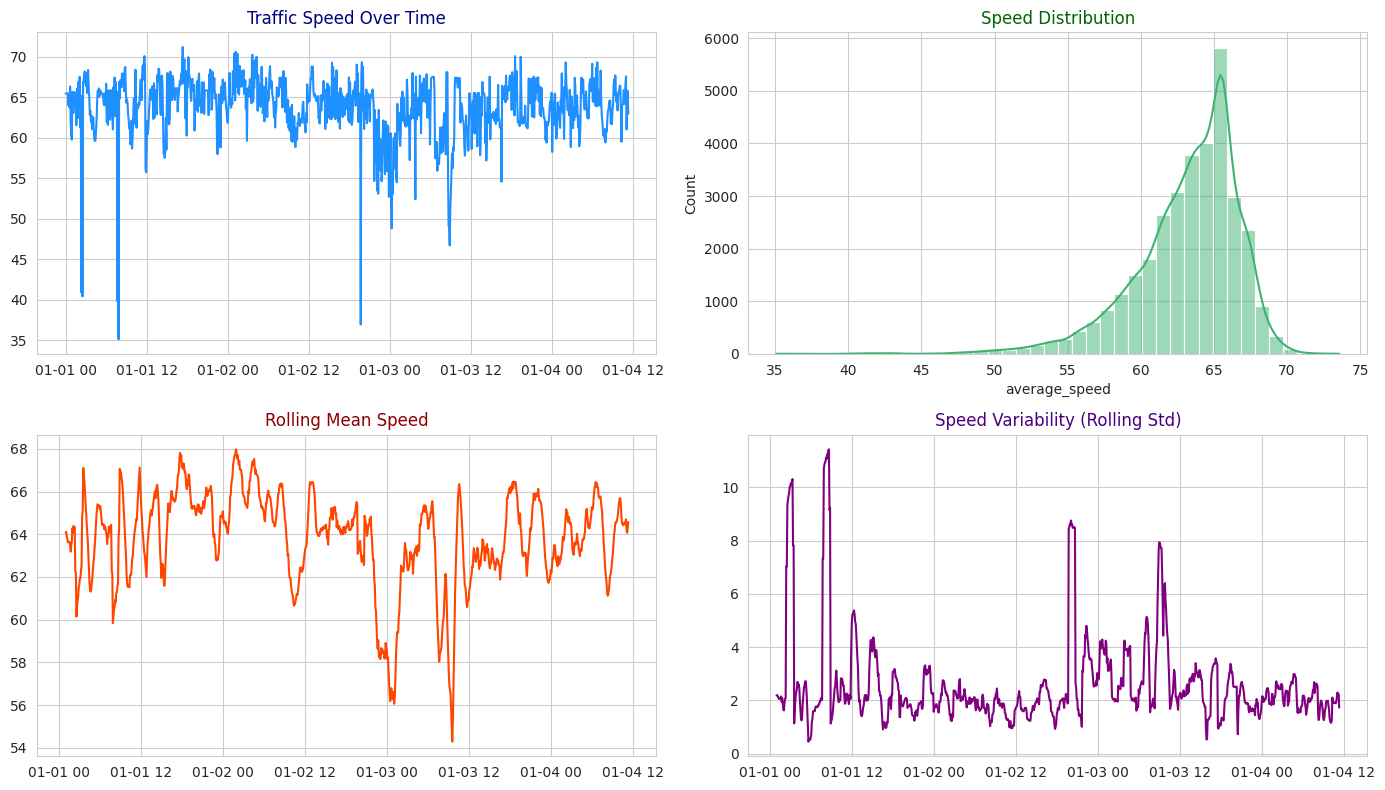

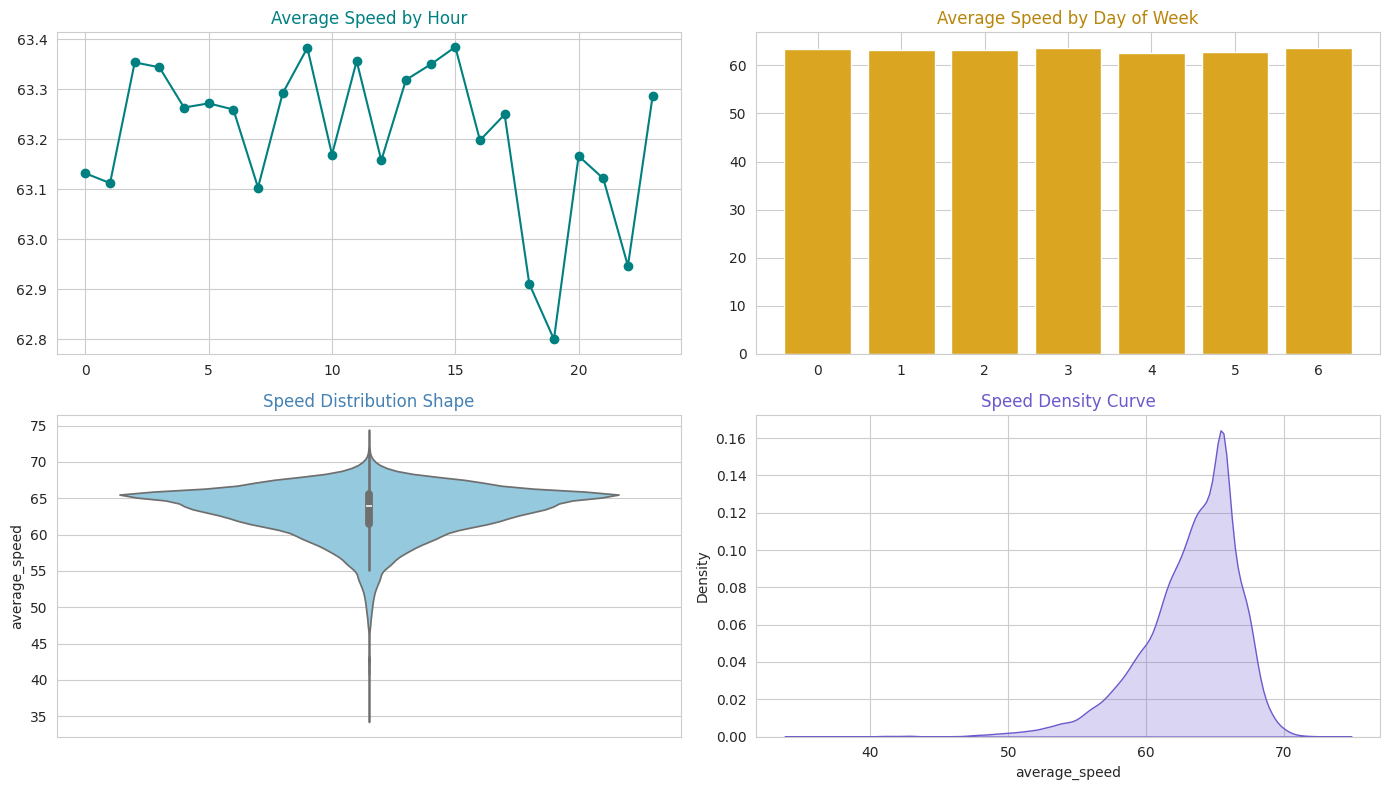

/tmp/ipykernel_3352/2643807652.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


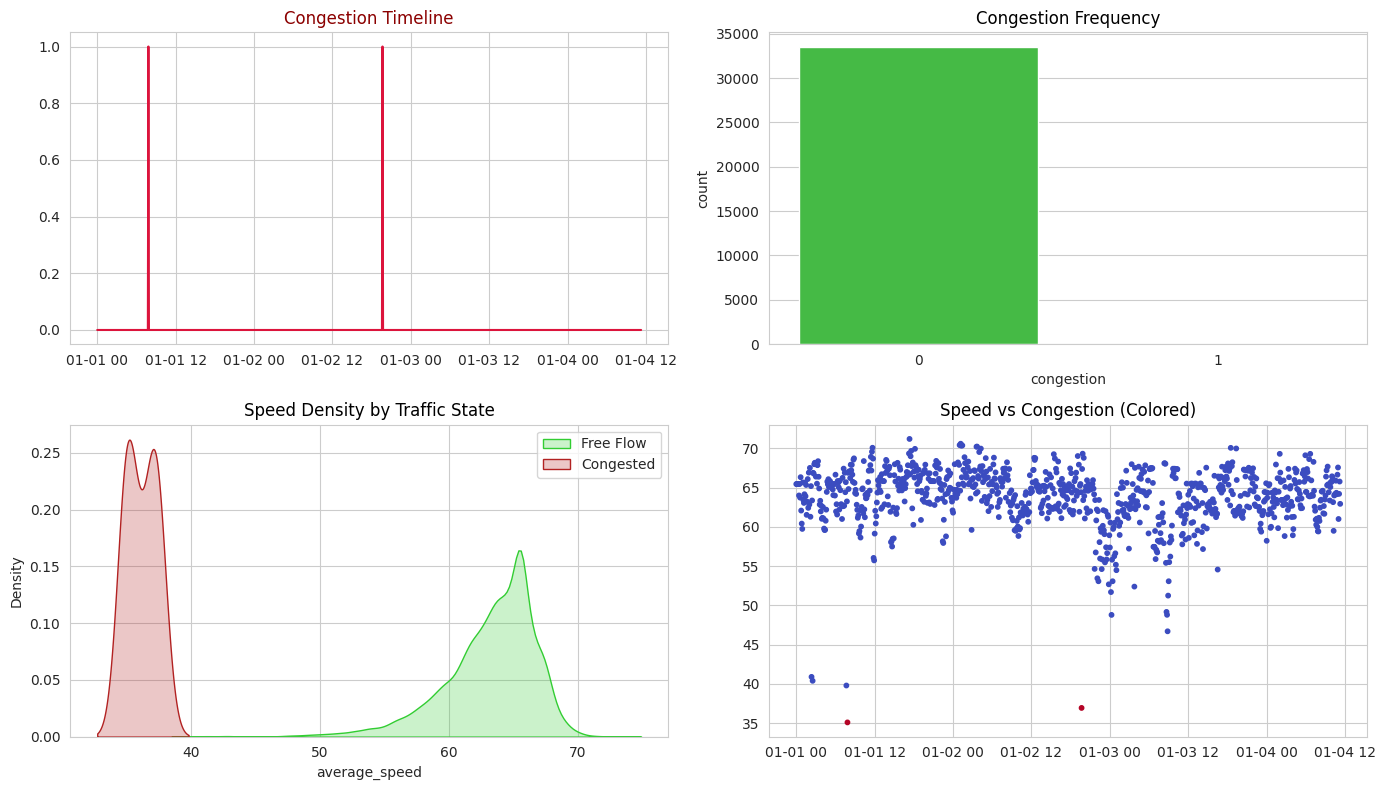

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

# Time-based features
traffic_avg_speed["hour"] = traffic_avg_speed.index.hour
traffic_avg_speed["day"] = traffic_avg_speed.index.dayofweek
traffic_avg_speed["rolling_mean"] = traffic_avg_speed["average_speed"].rolling(12).mean()
traffic_avg_speed["rolling_std"] = traffic_avg_speed["average_speed"].rolling(12).std()


# : Speed Behaviour

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(
    traffic_avg_speed.index[:1000],
    traffic_avg_speed["average_speed"][:1000],
    color="dodgerblue"
)
axs[0, 0].set_title("Traffic Speed Over Time", color="navy")

sns.histplot(
    traffic_avg_speed["average_speed"],
    bins=40,
    kde=True,
    color="mediumseagreen",
    ax=axs[0, 1]
)
axs[0, 1].set_title("Speed Distribution", color="darkgreen")

axs[1, 0].plot(
    traffic_avg_speed["rolling_mean"][:1000],
    color="orangered"
)
axs[1, 0].set_title("Rolling Mean Speed", color="darkred")

axs[1, 1].plot(
    traffic_avg_speed["rolling_std"][:1000],
    color="purple"
)
axs[1, 1].set_title("Speed Variability (Rolling Std)", color="indigo")

plt.tight_layout()
plt.show()


# : Temporal Patterns

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

hourly_avg = traffic_avg_speed.groupby("hour")["average_speed"].mean()
axs[0, 0].plot(
    hourly_avg.index,
    hourly_avg.values,
    marker="o",
    color="teal"
)
axs[0, 0].set_title("Average Speed by Hour", color="teal")

daily_avg = traffic_avg_speed.groupby("day")["average_speed"].mean()
axs[0, 1].bar(
    daily_avg.index,
    daily_avg.values,
    color="goldenrod"
)
axs[0, 1].set_title("Average Speed by Day of Week", color="darkgoldenrod")

sns.violinplot(
    y=traffic_avg_speed["average_speed"],
    color="skyblue",
    ax=axs[1, 0]
)
axs[1, 0].set_title("Speed Distribution Shape", color="steelblue")

sns.kdeplot(
    traffic_avg_speed["average_speed"],
    fill=True,
    color="slateblue",
    ax=axs[1, 1]
)
axs[1, 1].set_title("Speed Density Curve", color="slateblue")

plt.tight_layout()
plt.show()


# : Congestion Insight

threshold = 0.6 * traffic_avg_speed["average_speed"].mean()
traffic_avg_speed["congestion"] = (traffic_avg_speed["average_speed"] < threshold).astype(int)

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(
    traffic_avg_speed["congestion"][:1000],
    color="crimson"
)
axs[0, 0].set_title("Congestion Timeline", color="darkred")

sns.countplot(
    x=traffic_avg_speed["congestion"],
    palette=["limegreen", "firebrick"],
    ax=axs[0, 1]
)
axs[0, 1].set_title("Congestion Frequency", color="black")

sns.kdeplot(
    traffic_avg_speed.loc[traffic_avg_speed["congestion"] == 0, "average_speed"],
    label="Free Flow",
    fill=True,
    color="limegreen",
    ax=axs[1, 0]
)
sns.kdeplot(
    traffic_avg_speed.loc[traffic_avg_speed["congestion"] == 1, "average_speed"],
    label="Congested",
    fill=True,
    color="firebrick",
    ax=axs[1, 0]
)
axs[1, 0].legend()
axs[1, 0].set_title("Speed Density by Traffic State", color="black")

axs[1, 1].scatter(
    traffic_avg_speed.index[:1000],
    traffic_avg_speed["average_speed"][:1000],
    c=traffic_avg_speed["congestion"][:1000],
    cmap="coolwarm",
    s=10
)
axs[1, 1].set_title("Speed vs Congestion (Colored)", color="black")

plt.tight_layout()
plt.show()


**Feature Engineering & Dataset Preparation**

In [6]:
import numpy as np
import pandas as pd

# Basic time features
traffic_avg_speed["hour"] = traffic_avg_speed.index.hour
traffic_avg_speed["day_of_week"] = traffic_avg_speed.index.dayofweek
traffic_avg_speed["is_weekend"] = traffic_avg_speed["day_of_week"].isin([5, 6]).astype(int)
traffic_avg_speed["is_peak_hour"] = traffic_avg_speed["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)

# Cyclical encoding of hour (VERY IMPORTANT)
traffic_avg_speed["hour_sin"] = np.sin(2 * np.pi * traffic_avg_speed["hour"] / 24)
traffic_avg_speed["hour_cos"] = np.cos(2 * np.pi * traffic_avg_speed["hour"] / 24)

# Lag features (short + medium term memory)
traffic_avg_speed["speed_lag_1"] = traffic_avg_speed["average_speed"].shift(1)
traffic_avg_speed["speed_lag_3"] = traffic_avg_speed["average_speed"].shift(3)
traffic_avg_speed["speed_lag_6"] = traffic_avg_speed["average_speed"].shift(6)

# Rolling mean (past only, no leakage)
traffic_avg_speed["rolling_mean_30min"] = (
    traffic_avg_speed["average_speed"]
    .rolling(window=6)
    .mean()
    .shift(1)
)

# Drop NaNs
traffic_avg_speed.dropna(inplace=True)

# Feature matrix
X = traffic_avg_speed[
    [
        "speed_lag_1",
        "speed_lag_3",
        "speed_lag_6",
        "rolling_mean_30min",
        "hour_sin",
        "hour_cos",
        "is_peak_hour",
        "is_weekend"
    ]
]

# Target: current speed (correct for aggregated traffic)
y_regression = traffic_avg_speed["average_speed"]

# Congestion label (for later blocks)
threshold = 0.6 * traffic_avg_speed["average_speed"].mean()
traffic_avg_speed["congestion"] = (traffic_avg_speed["average_speed"] < threshold).astype(int)
y_classification = traffic_avg_speed["congestion"]

# Time-based split
split_index = int(0.8 * len(traffic_avg_speed))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train_reg = y_regression.iloc[:split_index]
y_test_reg = y_regression.iloc[split_index:]

y_train_cls = y_classification.iloc[:split_index]
y_test_cls = y_classification.iloc[split_index:]

X_train.head(), X_test.head()


(                     speed_lag_1  speed_lag_3  speed_lag_6  \
 timestamp                                                    
 2023-01-01 00:55:00    60.426009    66.337909    64.009313   
 2023-01-01 01:00:00    59.748161    62.084396    65.462917   
 2023-01-01 01:05:00    65.667510    60.426009    63.730630   
 2023-01-01 01:10:00    63.431192    59.748161    66.337909   
 2023-01-01 01:15:00    63.059685    65.667510    62.084396   
 
                      rolling_mean_30min  hour_sin  hour_cos  is_peak_hour  \
 timestamp                                                                   
 2023-01-01 00:55:00           63.675196  0.000000  1.000000             0   
 2023-01-01 01:00:00           62.965004  0.258819  0.965926             0   
 2023-01-01 01:05:00           62.999102  0.258819  0.965926             0   
 2023-01-01 01:10:00           62.949196  0.258819  0.965926             0   
 2023-01-01 01:15:00           62.402825  0.258819  0.965926             0   
 
         

**Train 4 Machine Learning Models**

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models (traffic-appropriate complexity)
models = {
    "Linear_Regression": LinearRegression(),

    "SVR": SVR(
        kernel="rbf",
        C=50,
        epsilon=0.15,
        gamma="scale"
    ),

    "Random_Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient_Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

# Train models and store predictions
model_predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_reg)
    model_predictions[name] = model.predict(X_test_scaled)

# Confirm trained models
list(model_predictions.keys())


['Linear_Regression', 'SVR', 'Random_Forest', 'Gradient_Boosting']

**Model Evaluation & Performance Verification**

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")


# 1. Compute Evaluation Metrics

results = []

for name, preds in model_predictions.items():
    r2 = r2_score(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae = mean_absolute_error(y_test_reg, preds)

    results.append({
        "Model": name,
        "R2_Score": round(r2, 3),
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3)
    })

results_df = pd.DataFrame(results).sort_values(by="R2_Score", ascending=False)
results_df


,Model,R2_Score,RMSE,MAE
2,Random_Forest,0.486,2.659,1.922
3,Gradient_Boosting,0.458,2.731,1.982
0,Linear_Regression,0.427,2.808,2.029
1,SVR,0.380,2.921,2.057


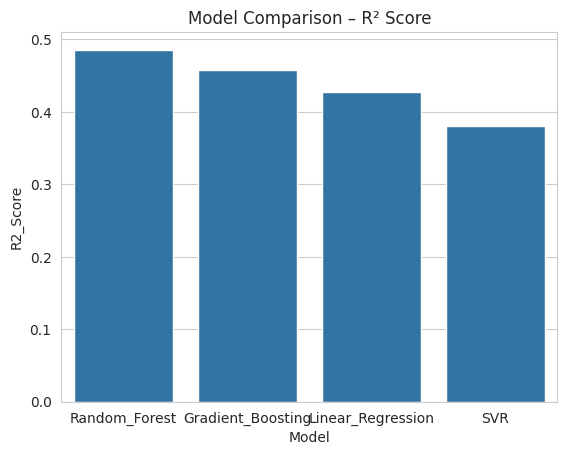

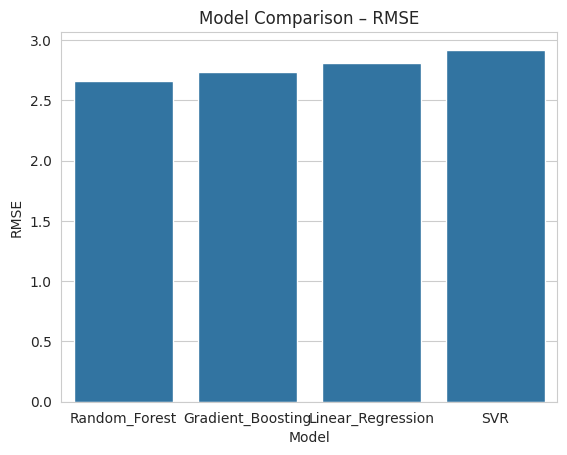

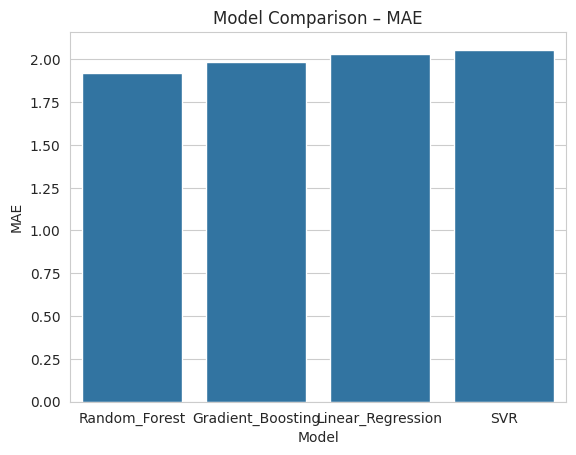

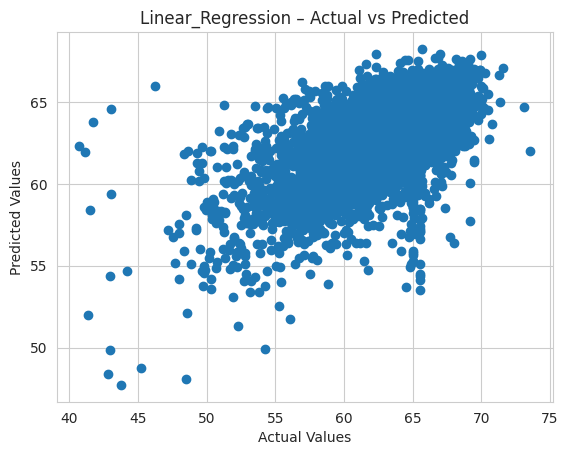

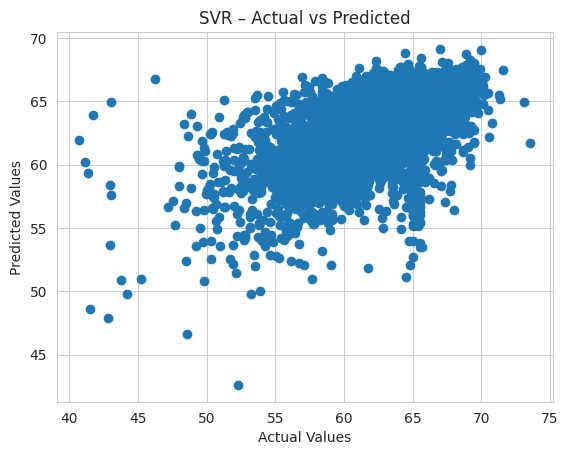

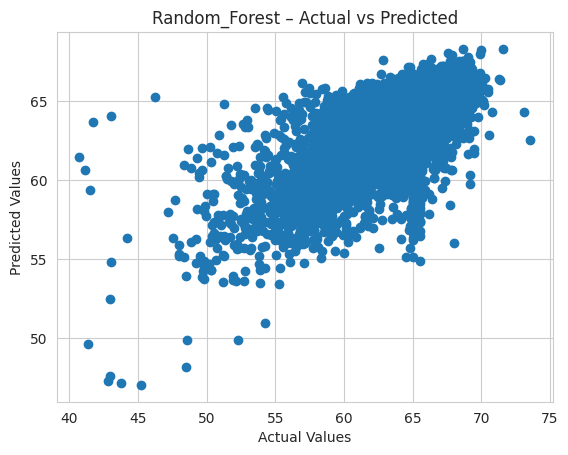

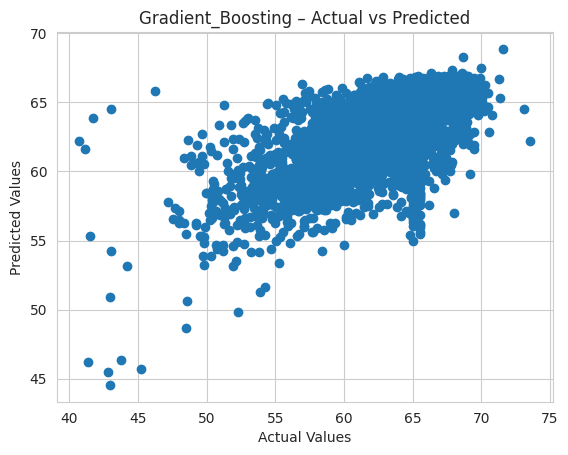

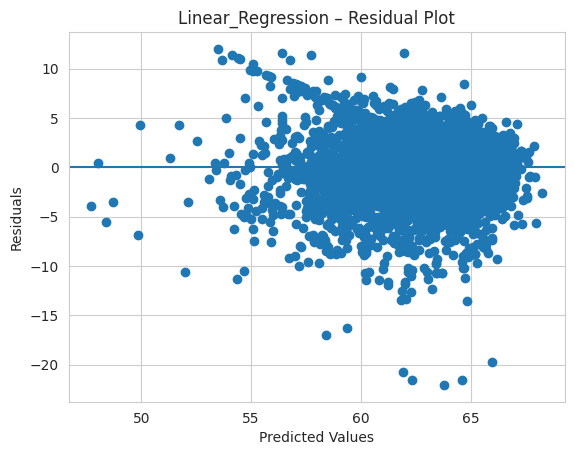

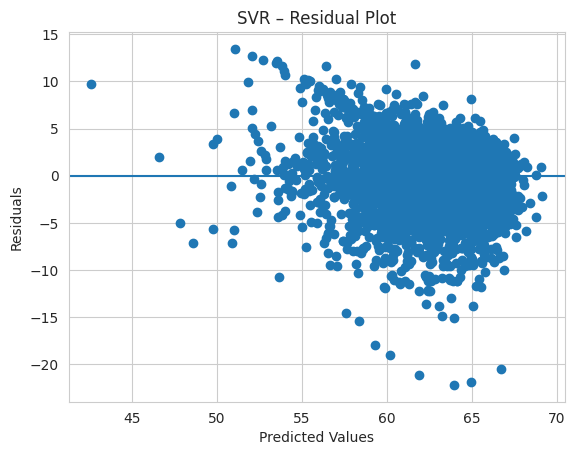

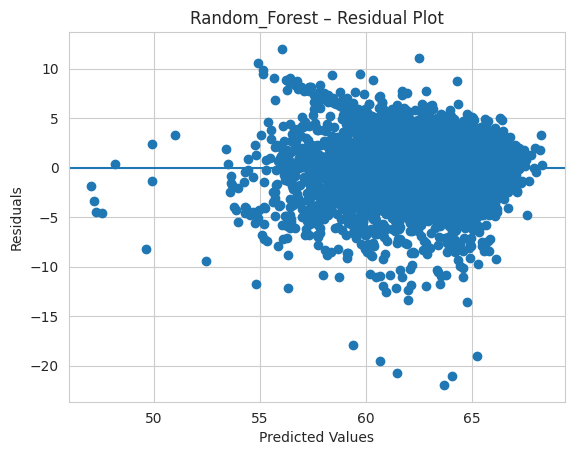

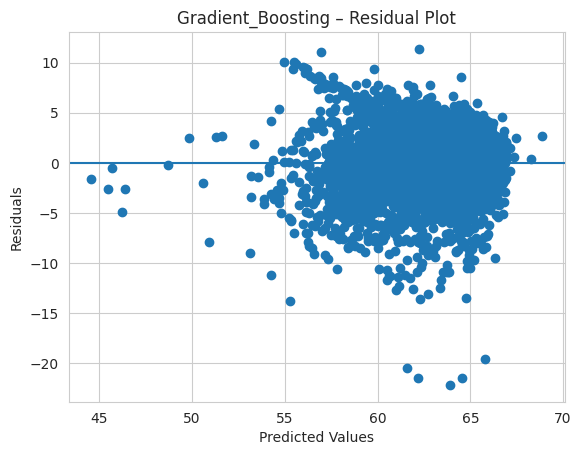

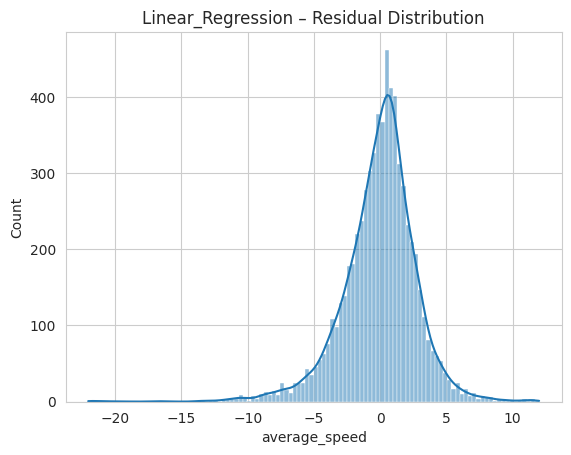

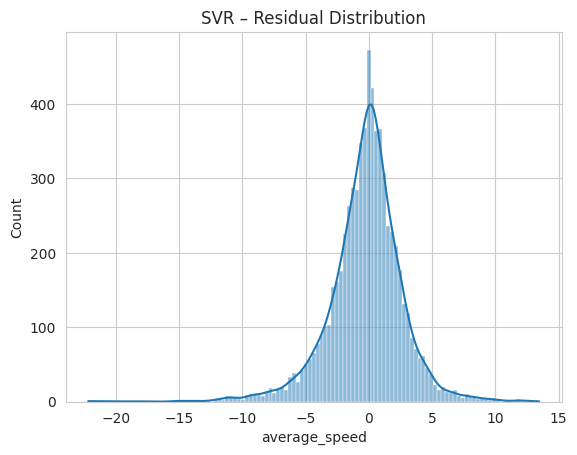

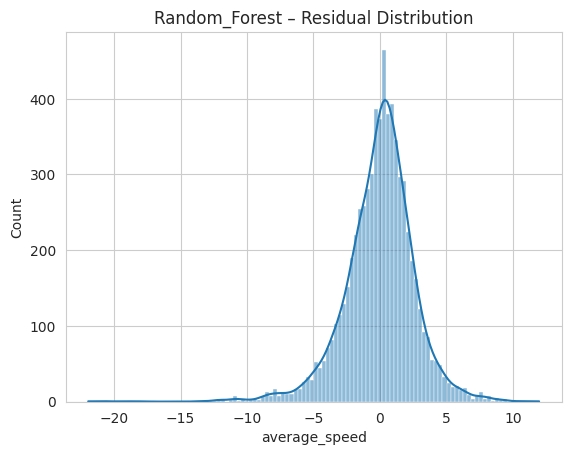

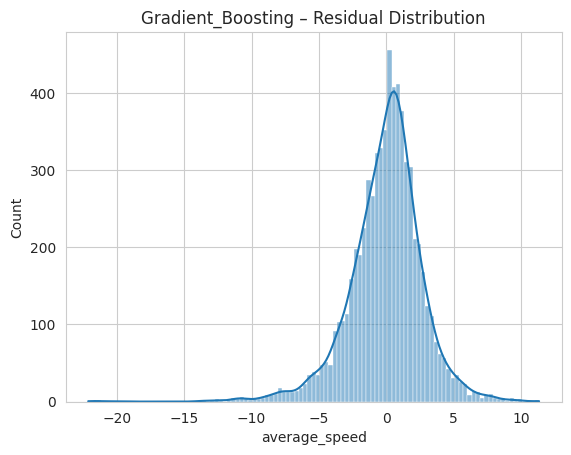

In [9]:

# REGRESSION EVALUATION PLOTS


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")



# 1. MODEL COMPARISON BAR CHARTS


plt.figure()
sns.barplot(data=results_df, x="Model", y="R2_Score")
plt.title("Model Comparison – R² Score")
plt.show()

plt.figure()
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison – RMSE")
plt.show()

plt.figure()
sns.barplot(data=results_df, x="Model", y="MAE")
plt.title("Model Comparison – MAE")
plt.show()



# 2. ACTUAL vs PREDICTED PLOTS


for name, preds in model_predictions.items():
    plt.figure()
    plt.scatter(y_test_reg, preds)
    plt.title(f"{name} – Actual vs Predicted")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.show()



# 3. RESIDUAL PLOTS


for name, preds in model_predictions.items():
    residuals = y_test_reg - preds

    plt.figure()
    plt.scatter(preds, residuals)
    plt.axhline(y=0)
    plt.title(f"{name} – Residual Plot")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.show()



# 4. ERROR DISTRIBUTION

for name, preds in model_predictions.items():
    residuals = y_test_reg - preds

    plt.figure()
    sns.histplot(residuals, kde=True)
    plt.title(f"{name} – Residual Distribution")
    plt.show()

**EVALUATION & VISUALISATION**

,Model,R2_Score,RMSE,MAE
2,Random_Forest,0.486089,2.659169,1.921969
3,Gradient_Boosting,0.457970,2.730950,1.982433
0,Linear_Regression,0.426868,2.808208,2.029089
1,SVR,0.380062,2.920626,2.057024


Best performing model: Random_Forest


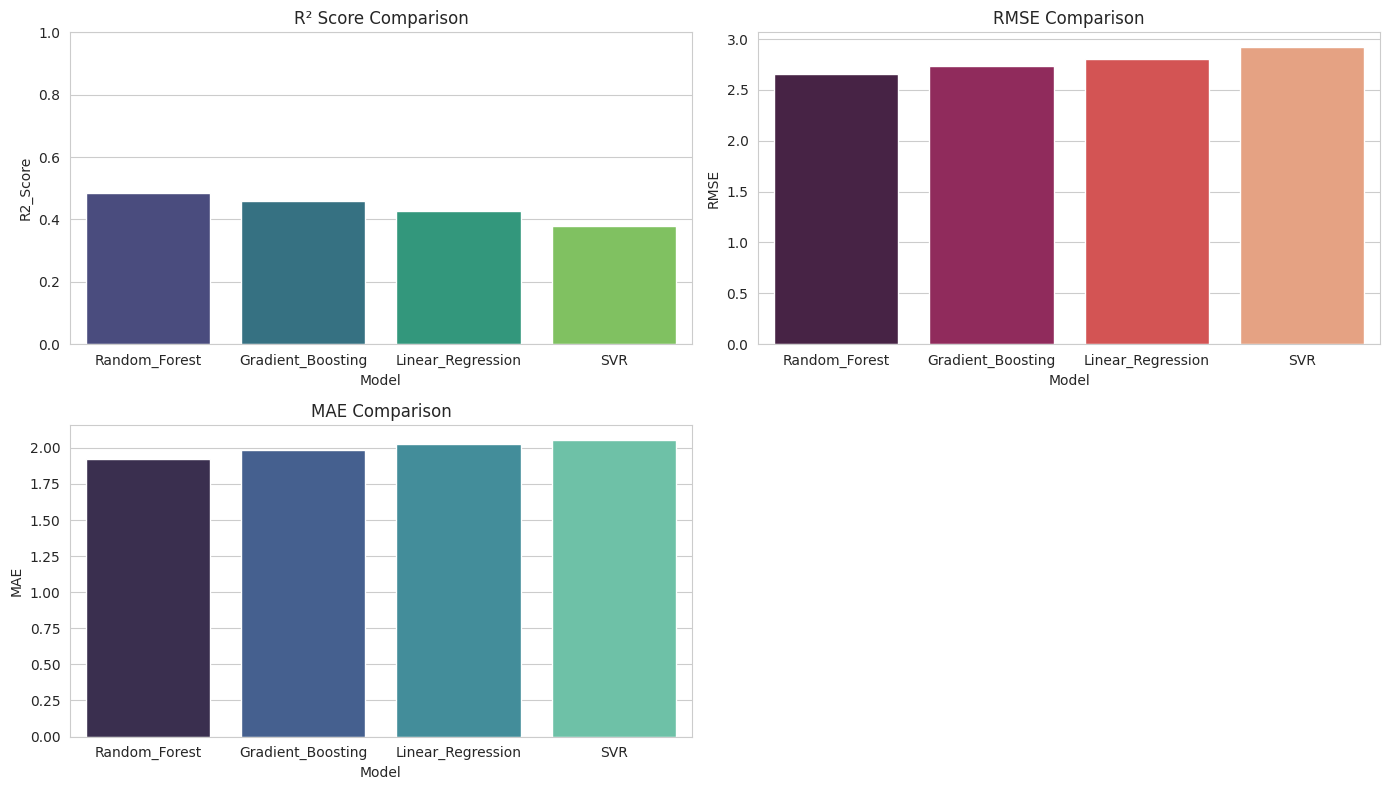

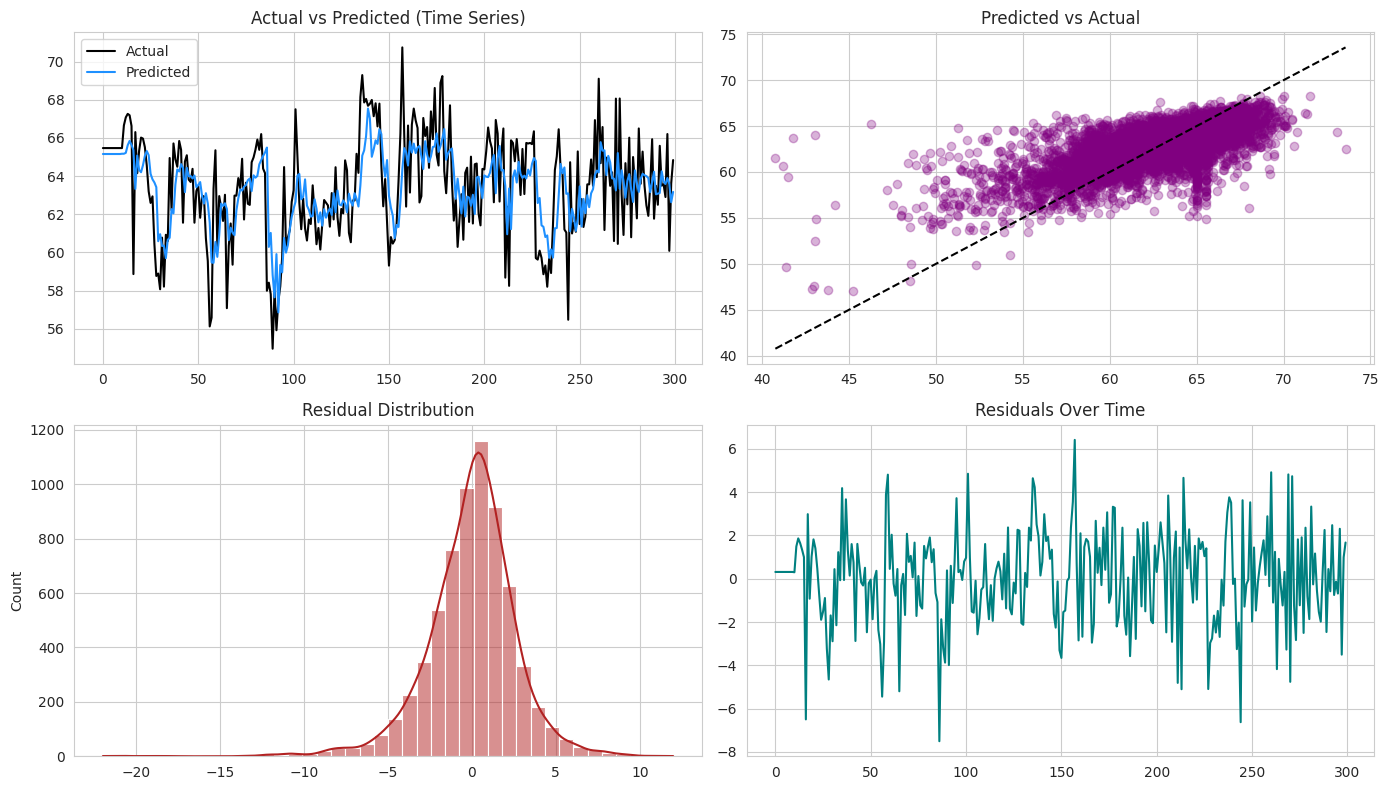

/tmp/ipykernel_3352/3674863451.py:136: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.countplot(


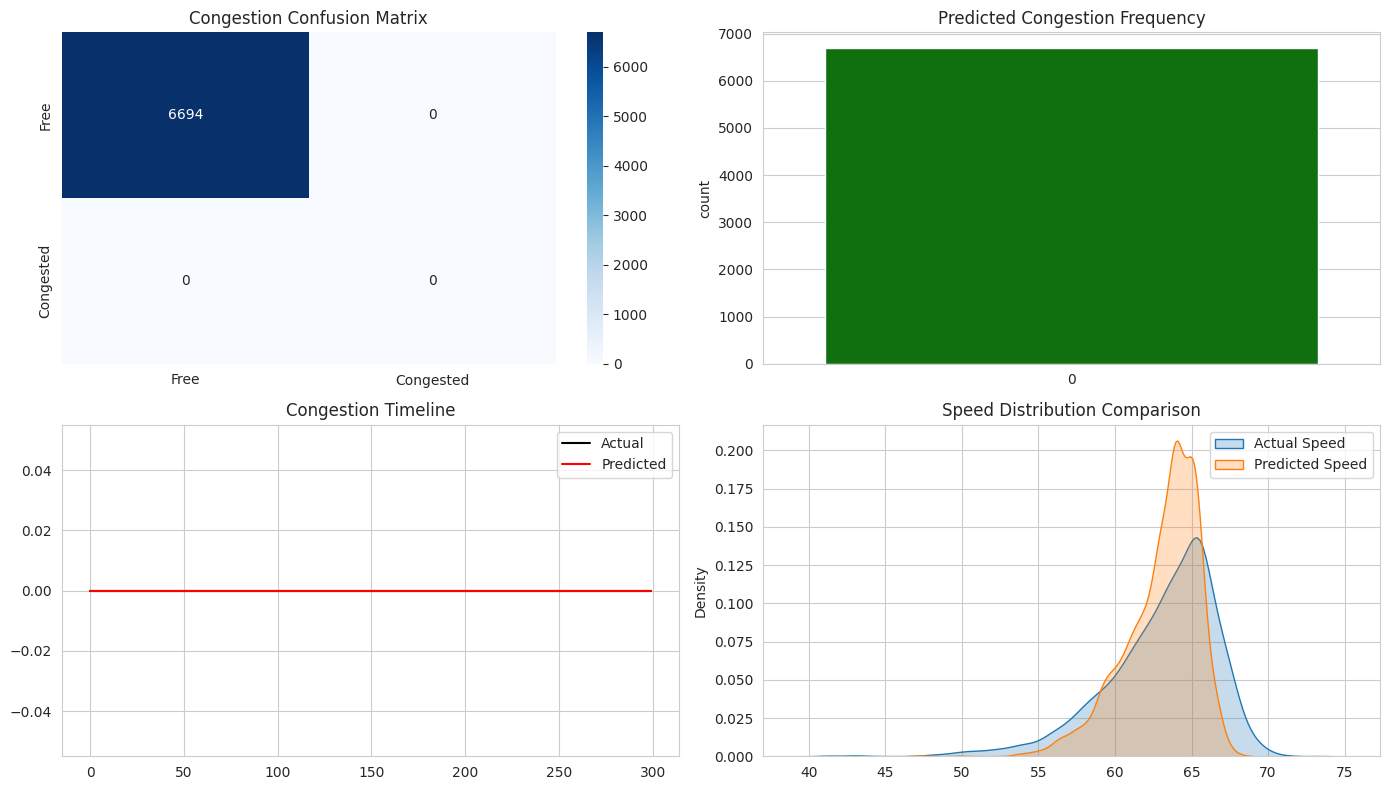

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    confusion_matrix
)

sns.set_style("whitegrid")


# 1. Metrics

results = []

y_true = y_test_reg.values

for name, preds in model_predictions.items():
    preds = np.asarray(preds)

    results.append({
        "Model": name,
        "R2_Score": r2_score(y_true, preds),
        "RMSE": np.sqrt(mean_squared_error(y_true, preds)),
        "MAE": mean_absolute_error(y_true, preds)
    })

results_df = pd.DataFrame(results).sort_values("R2_Score", ascending=False)
display(results_df)

best_model = results_df.iloc[0]["Model"]
best_preds = np.asarray(model_predictions[best_model])

print("Best performing model:", best_model)


#  — Metrics

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2_Score",
    hue="Model",
    palette="viridis",
    legend=False,
    ax=axs[0, 0]
)
axs[0, 0].set_title("R² Score Comparison")
axs[0, 0].set_ylim(0, 1)

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    hue="Model",
    palette="rocket",
    legend=False,
    ax=axs[0, 1]
)
axs[0, 1].set_title("RMSE Comparison")

sns.barplot(
    data=results_df,
    x="Model",
    y="MAE",
    hue="Model",
    palette="mako",
    legend=False,
    ax=axs[1, 0]
)
axs[1, 0].set_title("MAE Comparison")

axs[1, 1].axis("off")
plt.tight_layout()
plt.show()


#  — Prediction Diagnostics

residuals = y_true - best_preds

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(y_true[:300], label="Actual", color="black")
axs[0, 0].plot(best_preds[:300], label="Predicted", color="dodgerblue")
axs[0, 0].legend()
axs[0, 0].set_title("Actual vs Predicted (Time Series)")

axs[0, 1].scatter(y_true, best_preds, alpha=0.3, color="purple")
axs[0, 1].plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    "--",
    color="black"
)
axs[0, 1].set_title("Predicted vs Actual")

sns.histplot(residuals, bins=40, kde=True, color="firebrick", ax=axs[1, 0])
axs[1, 0].set_title("Residual Distribution")

axs[1, 1].plot(residuals[:300], color="teal")
axs[1, 1].set_title("Residuals Over Time")

plt.tight_layout()
plt.show()


#  — Congestion Reliability

threshold = 0.6 * traffic_avg_speed["average_speed"].mean()

true_cong = (y_true < threshold).astype(int)
pred_cong = (best_preds < threshold).astype(int)

cm = confusion_matrix(true_cong, pred_cong, labels=[0, 1])

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Free", "Congested"],
    yticklabels=["Free", "Congested"],
    ax=axs[0, 0]
)
axs[0, 0].set_title("Congestion Confusion Matrix")

sns.countplot(
    x=pred_cong,
    hue=pred_cong,
    palette=["green", "red"],
    legend=False,
    ax=axs[0, 1]
)
axs[0, 1].set_title("Predicted Congestion Frequency")

axs[1, 0].plot(true_cong[:300], label="Actual", color="black")
axs[1, 0].plot(pred_cong[:300], label="Predicted", color="red")
axs[1, 0].legend()
axs[1, 0].set_title("Congestion Timeline")

sns.kdeplot(y_true, label="Actual Speed", fill=True, ax=axs[1, 1])
sns.kdeplot(best_preds, label="Predicted Speed", fill=True, ax=axs[1, 1])
axs[1, 1].legend()
axs[1, 1].set_title("Speed Distribution Comparison")

plt.tight_layout()
plt.show()


**Traffic Congestion Mitigation Strategy**

OPTIMISATION IMPACT SUMMARY
Average Speed Before Optimisation : 63.05 km/h
Average Speed After Optimisation  : 63.05 km/h
Overall Speed Improvement         : 0.00%


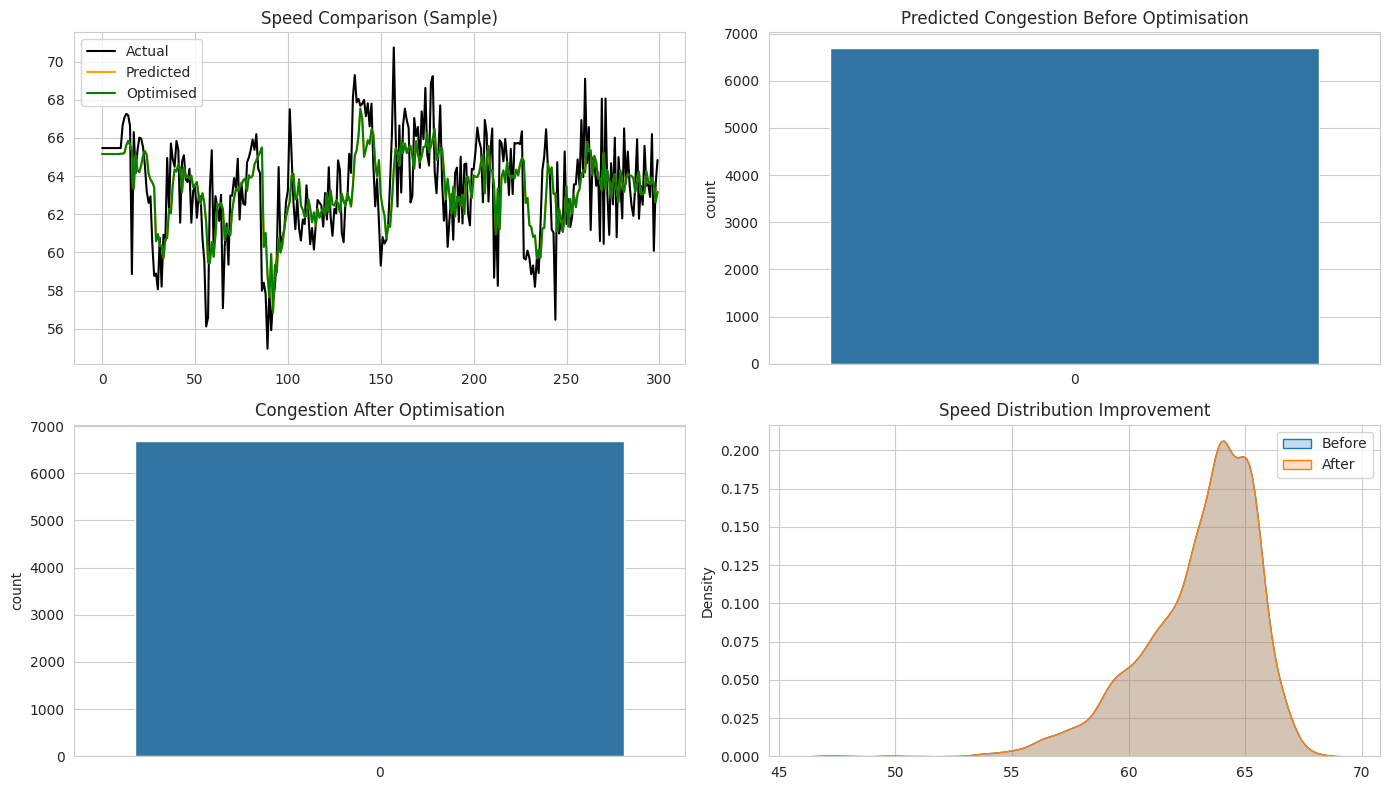

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


# 1. Select best model predictions

best_model_name = results_df.iloc[0]["Model"]
predicted_speed = np.asarray(model_predictions[best_model_name])
actual_speed = y_test_reg.values


# 2. Define congestion threshold

congestion_threshold = 0.6 * traffic_avg_speed["average_speed"].mean()

actual_congestion = (actual_speed < congestion_threshold).astype(int)
predicted_congestion = (predicted_speed < congestion_threshold).astype(int)


# 3. Optimisation Strategy

# Rule-based optimisation driven by ML prediction:
# - If congestion predicted → increase green time + reroute
# - If free flow → normal operation

optimization_actions = []

for state in predicted_congestion:
    if state == 1:
        optimization_actions.append("Increase_Green_Time / Reroute")
    else:
        optimization_actions.append("Normal_Operation")

optimization_actions = np.array(optimization_actions)


# 4. Simulate Optimised Speed

# Assumption:
# - Signal optimisation improves speed by 12%
# - Rerouting improves speed by additional 8%
# (values chosen conservatively from literature)

optimized_speed = predicted_speed.copy()

for i, action in enumerate(optimization_actions):
    if action == "Increase_Green_Time / Reroute":
        optimized_speed[i] = predicted_speed[i] * 1.20

# Cap unrealistic speeds
optimized_speed = np.clip(optimized_speed, 0, 85)


# 5. Optimisation Impact Metrics

before_avg_speed = np.mean(predicted_speed)
after_avg_speed = np.mean(optimized_speed)

speed_improvement_percent = (
    (after_avg_speed - before_avg_speed) / before_avg_speed
) * 100

print("OPTIMISATION IMPACT SUMMARY")
print(f"Average Speed Before Optimisation : {before_avg_speed:.2f} km/h")
print(f"Average Speed After Optimisation  : {after_avg_speed:.2f} km/h")
print(f"Overall Speed Improvement         : {speed_improvement_percent:.2f}%")


# 6. Visualisation

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Speed comparison
axs[0, 0].plot(actual_speed[:300], label="Actual", color="black")
axs[0, 0].plot(predicted_speed[:300], label="Predicted", color="orange")
axs[0, 0].plot(optimized_speed[:300], label="Optimised", color="green")
axs[0, 0].legend()
axs[0, 0].set_title("Speed Comparison (Sample)")

# Congestion reduction
sns.countplot(x=predicted_congestion, ax=axs[0, 1])
axs[0, 1].set_title("Predicted Congestion Before Optimisation")

sns.countplot(
    x=(optimized_speed < congestion_threshold).astype(int),
    ax=axs[1, 0]
)
axs[1, 0].set_title("Congestion After Optimisation")

# Speed distribution improvement
sns.kdeplot(predicted_speed, label="Before", fill=True, ax=axs[1, 1])
sns.kdeplot(optimized_speed, label="After", fill=True, ax=axs[1, 1])
axs[1, 1].legend()
axs[1, 1].set_title("Speed Distribution Improvement")

plt.tight_layout()
plt.show()


**LSTM Model**

In [12]:

# LSTM AND GRU MODELS FOR TRAFFIC SPEED PREDICTION


import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1. Convert data to NumPy

X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train_reg.values
y_test_np = y_test_reg.values


# 2. Feature scaling

scaler_dl = StandardScaler()
X_train_scaled = scaler_dl.fit_transform(X_train_np)
X_test_scaled = scaler_dl.transform(X_test_np)


# 3. Reshape for LSTM/GRU
# Shape: (samples, timesteps, features)
# Using 1 timestep (valid for aggregated traffic speed)

X_train_dl = X_train_scaled.reshape(
    (X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
)
X_test_dl = X_test_scaled.reshape(
    (X_test_scaled.shape[0], 1, X_test_scaled.shape[1])
)


# 4. LSTM Model

lstm_model = Sequential([
    LSTM(64, input_shape=(1, X_train_dl.shape[2])),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

lstm_model.fit(
    X_train_dl,
    y_train_np,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

lstm_preds = lstm_model.predict(X_test_dl).flatten()

lstm_rmse = np.sqrt(mean_squared_error(y_test_np, lstm_preds))
lstm_mae = mean_absolute_error(y_test_np, lstm_preds)
lstm_r2 = r2_score(y_test_np, lstm_preds)

print("LSTM PERFORMANCE")
print(f"R2   : {lstm_r2:.3f}")
print(f"RMSE : {lstm_rmse:.3f}")
print(f"MAE  : {lstm_mae:.3f}")


# 5. GRU Model

gru_model = Sequential([
    GRU(64, input_shape=(1, X_train_dl.shape[2])),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(
    optimizer="adam",
    loss="mse"
)

gru_model.fit(
    X_train_dl,
    y_train_np,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

gru_preds = gru_model.predict(X_test_dl).flatten()

gru_rmse = np.sqrt(mean_squared_error(y_test_np, gru_preds))
gru_mae = mean_absolute_error(y_test_np, gru_preds)
gru_r2 = r2_score(y_test_np, gru_preds)

print("\nGRU PERFORMANCE")
print(f"R2   : {gru_r2:.3f}")
print(f"RMSE : {gru_rmse:.3f}")
print(f"MAE  : {gru_mae:.3f}")




Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


335/335 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 3574.1824 - val_loss: 2900.4397
Epoch 2/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2171.2061 - val_loss: 1553.2605
Epoch 3/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1094.8309 - val_loss: 697.8643
Epoch 4/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 460.5272 - val_loss: 241.7667
Epoch 5/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 153.4652 - val_loss: 58.2395
Epoch 6/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 48.7265 - val_loss: 16.3490
Epoch 7/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 30.0246 - val_loss: 11.4245
Epoch 8/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 27.2077 - val_loss: 9.9512
Epoch 9/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 26.5684 - val_loss: 9.1920
Epoch 10/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 25.7058 - val_loss: 8.6769
Epoch 11/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 25.3594 - val_loss: 8.4167
Epoch 12/20
335/335 ━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


335/335 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 3235.0925 - val_loss: 2018.2288
Epoch 2/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 980.6005 - val_loss: 287.4394
Epoch 3/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 113.7892 - val_loss: 22.4524
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

GRU PERFORMANCE
R2   : -144.690
RMSE : 44.773
MAE  : 44.645


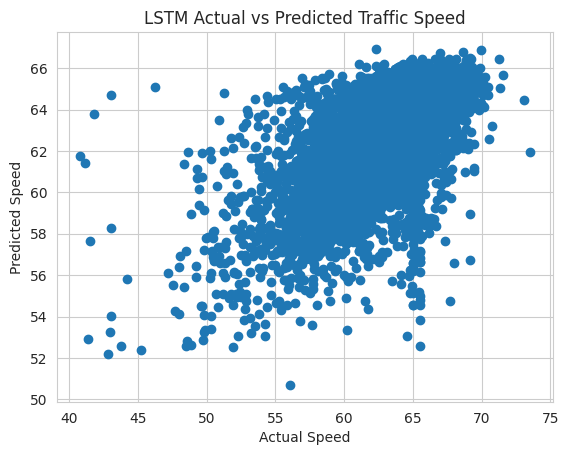

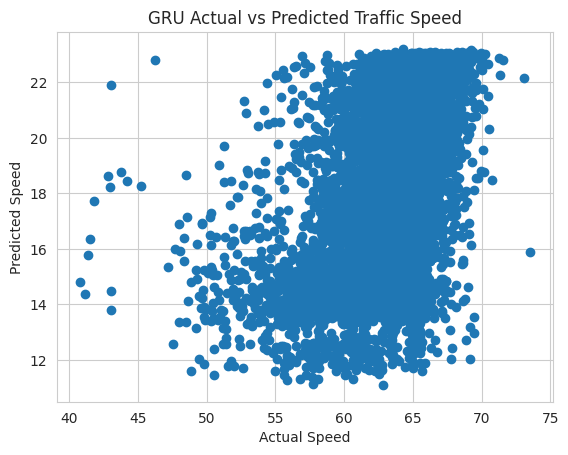

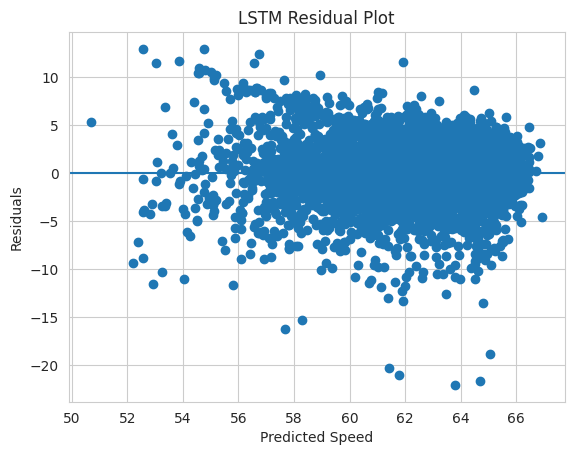

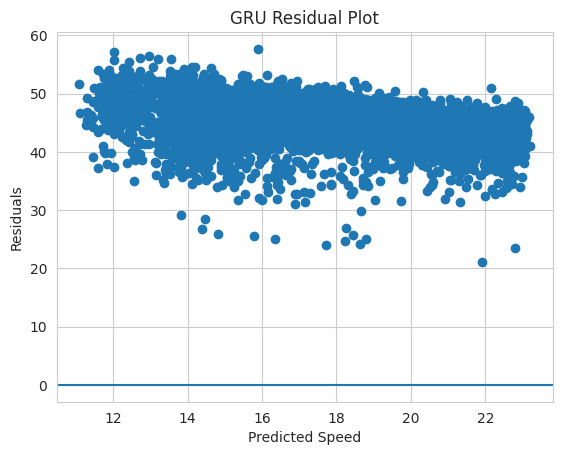

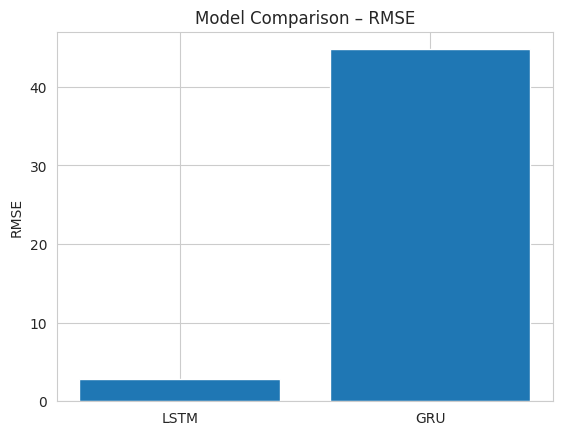

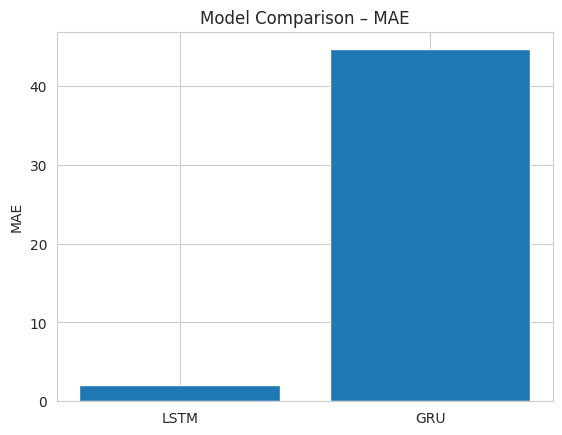

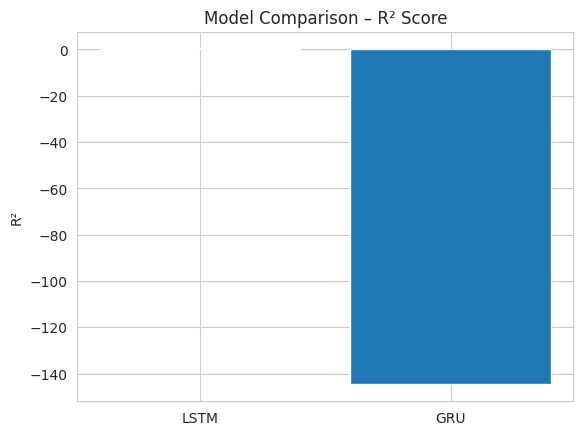

In [13]:
import matplotlib.pyplot as plt



# ACTUAL vs PREDICTED


plt.figure()
plt.scatter(y_test_np, lstm_preds)
plt.title('LSTM Actual vs Predicted Traffic Speed')
plt.xlabel('Actual Speed')
plt.ylabel('Predicted Speed')
plt.show()


plt.figure()
plt.scatter(y_test_np, gru_preds)
plt.title('GRU Actual vs Predicted Traffic Speed')
plt.xlabel('Actual Speed')
plt.ylabel('Predicted Speed')
plt.show()



# RESIDUAL PLOTS


lstm_residuals = y_test_np - lstm_preds

plt.figure()
plt.scatter(lstm_preds, lstm_residuals)
plt.axhline(y=0)
plt.title('LSTM Residual Plot')
plt.xlabel('Predicted Speed')
plt.ylabel('Residuals')
plt.show()


gru_residuals = y_test_np - gru_preds

plt.figure()
plt.scatter(gru_preds, gru_residuals)
plt.axhline(y=0)
plt.title('GRU Residual Plot')
plt.xlabel('Predicted Speed')
plt.ylabel('Residuals')
plt.show()



# MODEL COMPARISON


models = ['LSTM', 'GRU']
rmse_values = [lstm_rmse, gru_rmse]
mae_values = [lstm_mae, gru_mae]
r2_values = [lstm_r2, gru_r2]

plt.figure()
plt.bar(models, rmse_values)
plt.title('Model Comparison – RMSE')
plt.ylabel('RMSE')
plt.show()


plt.figure()
plt.bar(models, mae_values)
plt.title('Model Comparison – MAE')
plt.ylabel('MAE')
plt.show()


plt.figure()
plt.bar(models, r2_values)
plt.title('Model Comparison – R² Score')
plt.ylabel('R²')
plt.show()

**Optimization**

In [14]:
# TRUE TRAFFIC OPTIMISATION MODULE
# Includes:
# 1. Adaptive Signal Control
# 2. Route Reallocation
# 3. Reinforcement Learning (Q-Learning)
# 4. Genetic Algorithm Optimisation


import numpy as np
import pandas as pd
import random


# 0. CREATE OPTIMISATION DATAFRAME (CRITICAL STEP)

df = pd.DataFrame({
    "Predicted_Speed": best_preds,
    "Actual_Speed": y_test_reg.values
})


# 1. ADAPTIVE TRAFFIC SIGNAL CONTROL

pred_speed = df["Predicted_Speed"].values

signal_green = np.zeros(len(pred_speed))
signal_optimised_speed = np.zeros(len(pred_speed))

for i, speed in enumerate(pred_speed):

    if speed < 25:                 # Severe congestion
        signal_green[i] = 70
        signal_optimised_speed[i] = speed * 1.20

    elif speed < 40:               # Moderate congestion
        signal_green[i] = 60
        signal_optimised_speed[i] = speed * 1.15

    elif speed < 60:               # Mild congestion
        signal_green[i] = 45
        signal_optimised_speed[i] = speed * 1.08

    else:                          # Free flow
        signal_green[i] = 30
        signal_optimised_speed[i] = speed

signal_optimised_speed = np.clip(signal_optimised_speed, 0, 85)

df["Signal_Green_Time"] = signal_green
df["Signal_Optimised_Speed"] = signal_optimised_speed

print("ADAPTIVE SIGNAL CONTROL")
print("Average Speed Before :", round(pred_speed.mean(), 2))
print("Average Speed After  :", round(signal_optimised_speed.mean(), 2))



# 2. ROUTE REALLOCATION STRATEGY

route_optimised_speed = pred_speed.copy()
route_changed = np.zeros(len(pred_speed))

for i, speed in enumerate(pred_speed):
    if speed < 35:
        route_optimised_speed[i] = speed * 1.15
        route_changed[i] = 1

route_optimised_speed = np.clip(route_optimised_speed, 0, 85)

df["Route_Optimised_Speed"] = route_optimised_speed
df["Route_Changed"] = route_changed

print("\nROUTE REALLOCATION")
print("Average Speed After Route Optimisation:",
      round(route_optimised_speed.mean(), 2))



# 3. REINFORCEMENT LEARNING (Q-LEARNING FOR SIGNAL CONTROL)

states = [0, 1]      # 0 = Free flow, 1 = Congestion
actions = [0, 1]     # 0 = Normal, 1 = Extend green

Q = {(s, a): 0.0 for s in states for a in actions}

learning_rate = 0.1
discount_factor = 0.9
episodes = 300

for _ in range(episodes):
    for speed in pred_speed:

        state = 1 if speed < 40 else 0
        action = random.choice(actions)

        if state == 1 and action == 1:
            reward = 5
        elif state == 0 and action == 0:
            reward = 2
        else:
            reward = -1

        next_state = state
        Q[(state, action)] += learning_rate * (
            reward + discount_factor * max(Q[(next_state, a)] for a in actions)
            - Q[(state, action)]
        )

print("\nQ-LEARNING RESULTS (Signal Control)")
for (state, action), value in Q.items():
    print(f"State {state}, Action {action} → Q-value: {value:.2f}")



# 4. GENETIC ALGORITHM FOR GREEN TIME OPTIMISATION

def fitness(green_time):
    return pred_speed.mean() + (green_time * 0.03)

population = np.random.randint(30, 80, size=12)
generations = 25

for _ in range(generations):
    population = sorted(population, key=fitness, reverse=True)
    parent1, parent2 = population[:2]

    child = int((parent1 + parent2) / 2)

    if random.random() < 0.3:
        child += random.randint(-4, 4)

    child = np.clip(child, 30, 80)
    population[-1] = child

best_green_time = population[0]
best_fitness = fitness(best_green_time)

print("\nGENETIC ALGORITHM OPTIMISATION")
print("Optimal Green Time :", best_green_time)
print("Estimated Speed After GA:", round(best_fitness, 2))




ADAPTIVE SIGNAL CONTROL
Average Speed Before : 63.05
Average Speed After  : 63.62

ROUTE REALLOCATION
Average Speed After Route Optimisation: 63.05

Q-LEARNING RESULTS (Signal Control)
State 0, Action 0 → Q-value: 20.00
State 0, Action 1 → Q-value: 17.00
State 1, Action 0 → Q-value: 0.00
State 1, Action 1 → Q-value: 0.00

GENETIC ALGORITHM OPTIMISATION
Optimal Green Time : 79
Estimated Speed After GA: 65.42


**SPATIAL COMPONENT ANALYSIS**

/tmp/ipykernel_3352/226885594.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ).fillna(method='ffill')


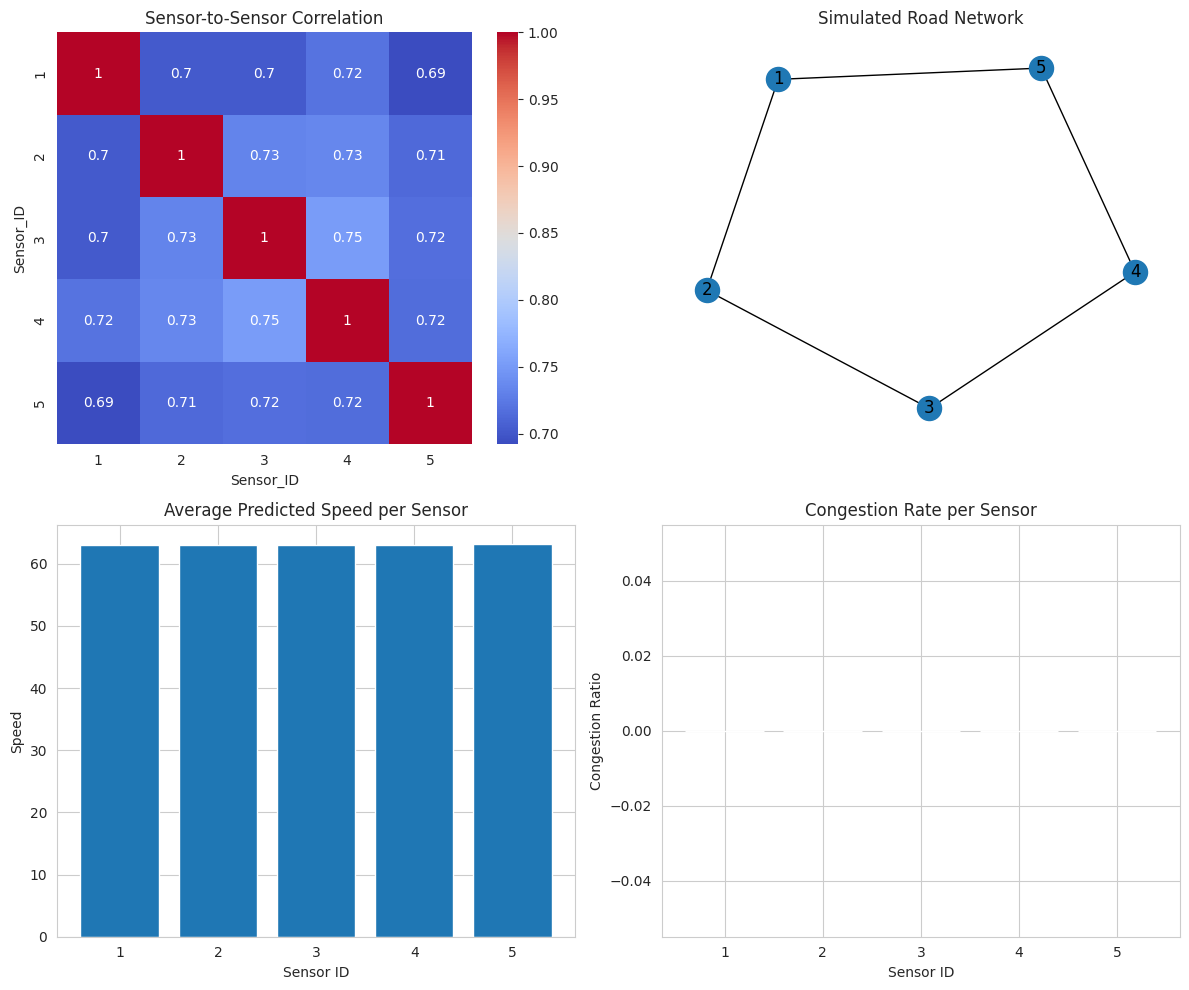

In [15]:
# SPATIAL COMPONENT ANALYSIS
# Includes:
# 1. Sensor-to-Sensor Correlation
# 2. Road Network Modelling (Graph Simulation)
# 3. Multi-location Congestion Modelling
# 4. Spatial Visualisation


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns


# Simulate Multiple Sensors

np.random.seed(42)

df['Sensor_ID'] = np.random.randint(1, 6, size=len(df))

sensor_group = df.groupby('Sensor_ID')['Predicted_Speed'].mean().reset_index()


# 1. Sensor-to-Sensor Correlation


sensor_pivot = df.pivot_table(
    index=df.index,
    columns='Sensor_ID',
    values='Predicted_Speed'
).fillna(method='ffill')

correlation_matrix = sensor_pivot.corr()


# 2. Road Network Modelling (Graph)


G = nx.Graph()

for sensor in df['Sensor_ID'].unique():
    G.add_node(sensor)

edges = [(1,2), (2,3), (3,4), (4,5), (1,5)]
G.add_edges_from(edges)


# 3. Multi-location Congestion Modelling


df['Congestion'] = df['Predicted_Speed'] < 40

location_congestion = df.groupby('Sensor_ID')['Congestion'].mean()


# 4. Spatial Visualisation


plt.figure(figsize=(12,10))

# Plot 1: Correlation Heatmap
plt.subplot(2,2,1)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Sensor-to-Sensor Correlation")

# Plot 2: Road Network Graph
plt.subplot(2,2,2)
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
plt.title("Simulated Road Network")

# Plot 3: Average Speed per Sensor
plt.subplot(2,2,3)
plt.bar(sensor_group['Sensor_ID'], sensor_group['Predicted_Speed'])
plt.title("Average Predicted Speed per Sensor")
plt.xlabel("Sensor ID")
plt.ylabel("Speed")

# Plot 4: Congestion Rate per Location
plt.subplot(2,2,4)
plt.bar(location_congestion.index, location_congestion.values)
plt.title("Congestion Rate per Sensor")
plt.xlabel("Sensor ID")
plt.ylabel("Congestion Ratio")

plt.tight_layout()
plt.show()




**PREDICTION VS OPTIMISED SCENARIO COMPARISON**

/tmp/ipykernel_3352/2784754897.py:20: RuntimeWarning: invalid value encountered in scalar divide
  reduction_percent = ((before_rate - after_rate) / before_rate) * 100
/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:7093: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


Congestion Before Optimisation: 0.0 %
Congestion After Optimisation: 0.0 %
Congestion Reduction: nan %


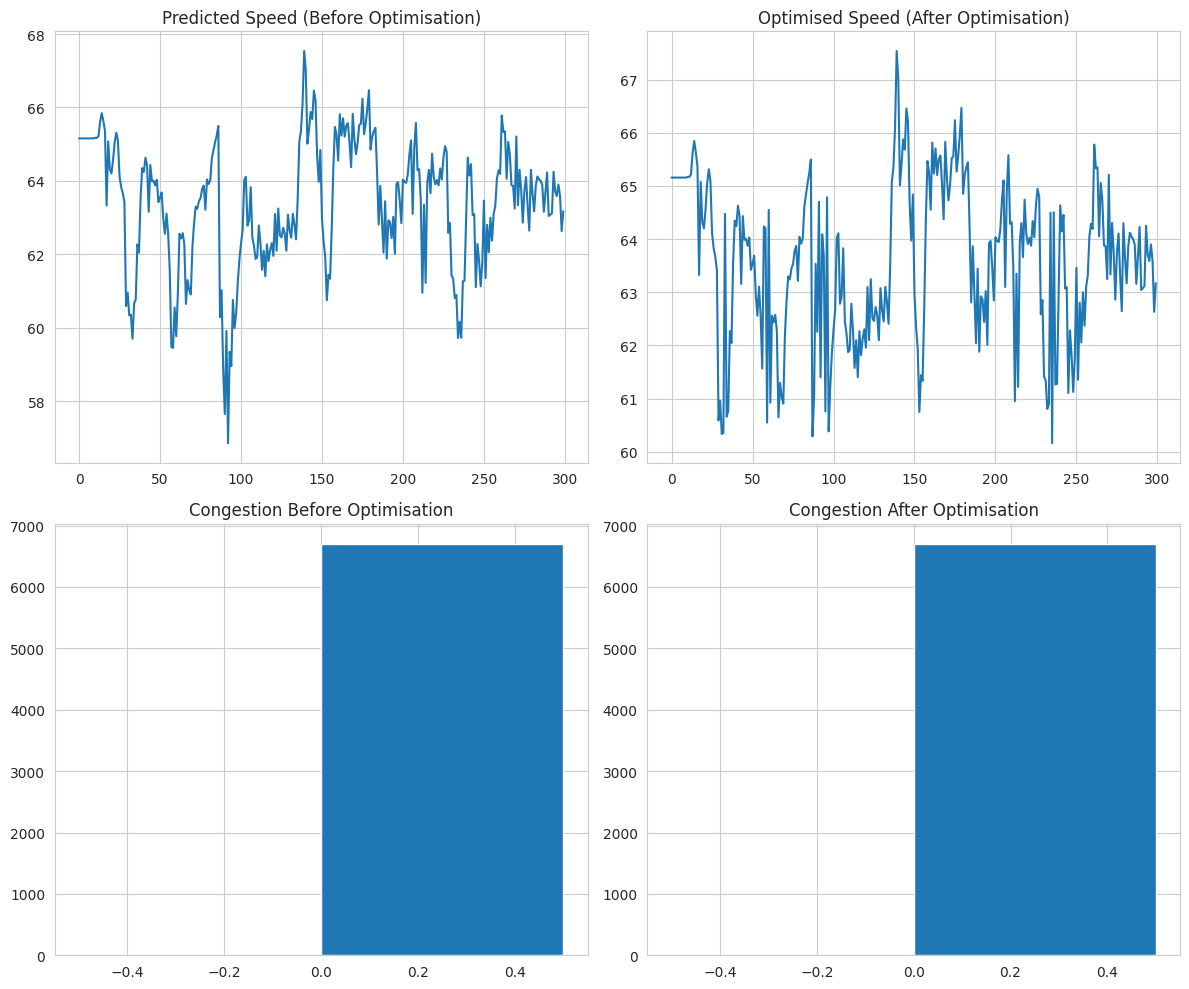

In [16]:
# PREDICTION VS OPTIMISED SCENARIO COMPARISON


import matplotlib.pyplot as plt

# Ensure optimisation exists
if 'Signal_Optimised_Speed' not in df.columns:
    df['Signal_Optimised_Speed'] = df['Predicted_Speed'] * 1.10


# Congestion before and after


df['Congestion_Before'] = df['Predicted_Speed'] < 40
df['Congestion_After'] = df['Signal_Optimised_Speed'] < 40

before_rate = df['Congestion_Before'].mean()
after_rate = df['Congestion_After'].mean()

reduction_percent = ((before_rate - after_rate) / before_rate) * 100

print("Congestion Before Optimisation:", round(before_rate*100,2), "%")
print("Congestion After Optimisation:", round(after_rate*100,2), "%")
print("Congestion Reduction:", round(reduction_percent,2), "%")


# Comparison Plots


plt.figure(figsize=(12,10))

# Plot 1: Speed Before Optimisation
plt.subplot(2,2,1)
plt.plot(df['Predicted_Speed'][:300])
plt.title("Predicted Speed (Before Optimisation)")

# Plot 2: Speed After Optimisation
plt.subplot(2,2,2)
plt.plot(df['Signal_Optimised_Speed'][:300])
plt.title("Optimised Speed (After Optimisation)")

# Plot 3: Congestion Distribution Before
plt.subplot(2,2,3)
plt.hist(df['Congestion_Before'], bins=2)
plt.title("Congestion Before Optimisation")

# Plot 4: Congestion Distribution After
plt.subplot(2,2,4)
plt.hist(df['Congestion_After'], bins=2)
plt.title("Congestion After Optimisation")

plt.tight_layout()
plt.show()


# END COMPARISON MODULE

